In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)
# rhs = generate_van_der_pol_rhs(0.01)

x0 = (10, 5)
dt = 0.01
t_span = (0, 50)

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

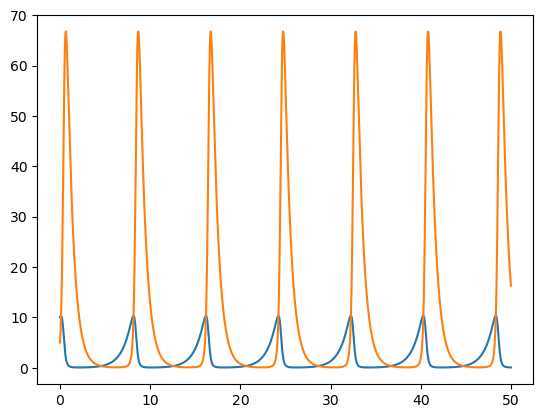

In [3]:
x_train = generate_training_data(rhs, x0, t_eval)

plt.plot(t_eval, x_train.T)
plt.show()

Text(0, 0.5, 'Amplitude')

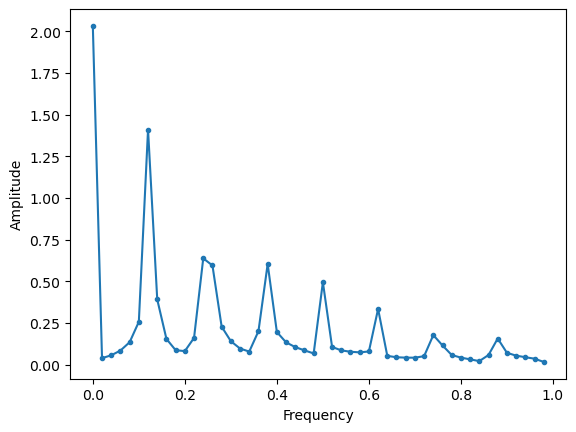

In [9]:
yf = np.fft.fft(x_train[0])

N = len(yf)
f = 1/dt
xf = np.linspace(0.0, f, N)

plt.plot(xf[:50], 1.0/N * np.abs(yf)[:50], '.-')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

In [6]:
np.mean(x_train[0]), 1/N * np.abs(yf[0])

(2.0321087192038942, 2.0321087192038942)

In [14]:
# n = 20

# sig_trunc = np.zeros_like(yf)
# for i in range(n + 1):
#     sig_trunc += 1.0/N * np.abs(yf[i]) * np.cos(i*t_eval/(2*np.pi) + np.angle(yf[i]))

# plt.plot(t_eval, sig_trunc, label='reconstructed')
# plt.plot(t_eval, x_train[0], label='true')
# plt.legend()

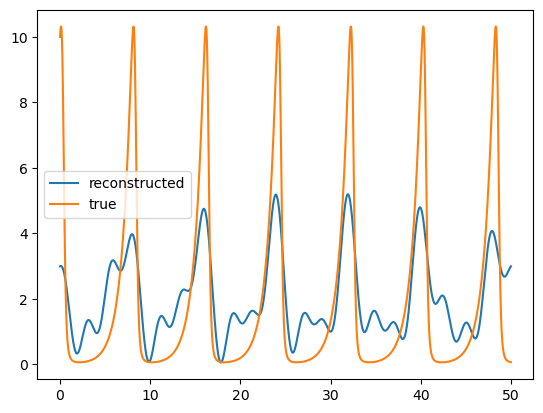

In [13]:
fft_trunc = np.zeros_like(yf, dtype=complex)

# n = 6
# fft_trunc[:n + 1] = yf[:n + 1]

idx = np.array([0, 6, 12, 13, 19])
fft_trunc[idx] = yf[idx]


sig_trunc = np.fft.ifft(fft_trunc)

plt.plot(t_eval, sig_trunc, label='reconstructed')
plt.plot(t_eval, x_train[0], label='true')
plt.legend()